# Open economy HANK

This notebook merges HANK with the Galí-Monacelli (2005) small open economy, following Auclert, Rognlie, Souchier, Straub (2024). We build one set of blocks that nests a representative-agent (RA) and a heterogeneous-agent (HA) version, calibrate both to the same steady state, and then trace out responses to foreign interest rate and monetary policy shocks. The key parameter throughout is the trade elasticity $\chi = \eta(1-\alpha) + \gamma$, which governs how strongly demand switches between home and foreign goods when the real exchange rate moves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj

In [2]:
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})

In [3]:
from household import hh, calibration
hh = hh.remap({'r': 'rp'})
calibration['rp'] = calibration['r']

In [4]:
# Compute steady state
ss = hh.steady_state(calibration)

In [5]:
# time horizon used here
T = 400

Augment the household calibration with the open-economy parameters: the home/foreign expenditure shares ($\alpha$, $\alpha^*$), the elasticities governing the trade elasticity $\chi$ ($\eta$ between home and foreign goods, $\gamma$ for foreign demand), and the steady-state objects (markup, foreign interest rate $r^*$, foreign consumption $C^*$). All prices and the real exchange rate $Q$ are normalized to 1 in steady state.

In [6]:
calibration |= {
               'alpha': 0.4,  # home's foreign good preference, (1 - alpha) is the home's home bias
               'alphastar': 0.4,  # foreign's home good preference, (1 - alpha_star) is the foreign's home bias
               'eta': 1.01,  # elasticity of substitution between goods
               'gamma': 0.394,  # elasticity of foreign demand
               'markup_ss': 1/ss['Z'],  # steady state markup
               'Y': 1,  # Output
               'nfa': 0,  # net foreign assets
               'rstar': ss['rp'],  # foreign interest rate
               'Cstar': 1,  # foreign consumption
               'Q': 1}  # Foreign demand

## Set up all the blocks

Beyond the household block, the open economy needs a handful of `SimpleBlock`s and `SolvedBlock`s: domestic and foreign demand, the UIP/relative-price block, the income/valuation block, balance of payments, and market clearing. These mirror the DAG in the lecture (shocks to $r^*$ or $r$, unknown $Y$, with $Q$ and prices determined along the way).

We'll need a few more `SimpleBlock`s.

First up, a block that splits up total domestic consumption `C` into home and foreign consumption, `cH` and `cF`.

In [7]:
@sj.simple
def dom_demand(C, PF_P, PH_P, eta, alpha):
    cH = (1 - alpha) * PH_P ** (-eta) * C  # PH_P is the real (in domestic cons. good units) price of the home good consumed domestically
    cF = alpha * PF_P ** (-eta) * C  # PF_P is the real (in domestic cons. good units) price of the foreign good consumed domestically
    return cH, cF

Next, foreign demand for home goods.

In [8]:
@sj.simple
def for_demand(PHstar, alphastar, gamma, Cstar):
    cHstar = alphastar * PHstar ** (-gamma) * Cstar  # PHstar is the real (in domestic cons. good units) price of the home good consumed abroad
    return cHstar

Next, a UIP block. Under producer-currency pricing, uncovered interest parity ($1 + r_t = (1 + r^*_t)\,Q_{t+1}/Q_t$) pins down the real exchange rate `Q` from the home and foreign interest rates: a transitory rise in $r^*$ requires a real depreciation today that unwinds over time. Given `Q`, the block backs out the relative prices of the home good at home (`PH_P`) and abroad (`PHstar`) and of the foreign good at home (`PF_P`). It also assembles the trade elasticity $\chi = \eta(1-\alpha) + \gamma$, the central object of the lecture.

In [9]:
@sj.solved(unknowns={'Q': (0.01, 300.)}, targets=['uip'])
def UIP(Q, r, rstar, eta, alpha, gamma):
    # recursive equation for UIP to pin down RER Q
    uip = 1 + r - (1 + rstar) * Q(1) / Q
    
    # price of H goods abroad in terms of Q
    PHstar = ((Q ** (eta - 1) - alpha) / (1 - alpha)) ** (1 / (1 - eta))
    
    # price of H goods at home in terms of Q
    PH_P = ((1 - alpha * Q ** (1 - eta)) / (1 - alpha)) ** (1 / (1 - eta))
    
    # price of F goods at home in terms of Q
    PF_P = Q  # LOOP
    
    # let's also compute chi, as an important object in the theory
    chi = eta * (1-alpha) + gamma
    return uip, PHstar, PH_P, PF_P, chi

Next, a block for the production side. The HA households hold no bonds; instead they hold claims to capitalized firm profits, so this block computes real labor income `Z`, dividends `div`, and the equity valuation `J`. The valuation condition prices the equity, and the ex-post return `rp` (which includes revaluation) is what households actually earn. We also track `j_to_Z`, the assets-to-labor-income ratio, since we calibrate markups to match the household block's ratio.

In [10]:
@sj.solved(unknowns={'J': (0.001, 100.)}, targets=['valuation_cond'])
def income(Y, PH_P, J, r, markup_ss):
    # real labor income
    Z = 1 / markup_ss * PH_P * Y
    
    # real dividend
    div = (1 - 1 / markup_ss) * PH_P * Y   
    
    # nominal PPP adjusted GDP
    gdp = PH_P * Y
    
    # valuation condition to price the asset
    valuation_cond = div + J(1) / (1 + r) - J  # J = beginning of period valuation
    j = J(1) / (1 + r)  # j = end of period valuation
    
    # ex post interest rate incl revaluation
    rp = J / j(-1) - 1
    
    # get assets to labor income ratio (will need this to calibrate to the household block)
    j_to_Z = j / Z
    return j, valuation_cond, gdp, div, Z, rp, j_to_Z

Next, a balance-of-payments block. Net exports `NX` are the value of home goods sold abroad minus foreign goods bought at home, and net foreign assets `nfa` accumulate the trade surplus plus interest on past positions. In steady state trade is balanced, so `NX` and `nfa` are zero.

In [11]:
@sj.solved(unknowns={'nfa': (-100., 100.)}, targets=['nfa_cond'])
def bop(nfa, PH_P, cHstar, PF_P, cF, r):
    NX = PH_P * cHstar - PF_P * cF  # PH_P * Y - PF_P * cF - PH_P * cH
    nfa_cond = NX + (1 + r(-1)) * nfa(-1) - nfa
    return NX, nfa_cond

Finally, a market clearing block. Goods market clearing requires home output `Y` to equal home demand for the home good `cH` plus foreign demand `cHstar`. Asset market clearing requires household assets `A` to equal the value of domestic equity `j` plus net foreign assets `nfa`.

In [12]:
@sj.simple
def mkt_clearing(Y, cH, cHstar, A, nfa, j):
    goods_mkt = cH + cHstar - Y       # home output absorbed by home + foreign demand
    asset_mkt = A - nfa - j           # household assets = domestic equity + net foreign assets
    return goods_mkt, asset_mkt

With that, we are ready to define the model.

In [13]:
ha = sj.create_model([UIP, income, hh, dom_demand, for_demand, bop,  mkt_clearing], name="HA Model")

Let's also set up the RA model. It shares every block with the HA model except the household: instead of the heterogeneous-agent block we use a representative consumer with a standard Euler equation and budget constraint. The RA version is (almost) literally Galí-Monacelli, and serves as the benchmark against which the HA channels are measured.

In [14]:
@sj.solved(unknowns={'C': 1, 'A': 1},
           targets=["euler", "budget_constraint"])  # solver="broyden_custom")
def hh_ra(C, A, Z, eis, beta, rp):
    euler = (beta * (1 + rp(+1)))**(-eis) * C(+1) - C
    budget_constraint = (1 + rp) * A(-1) + Z - C - A
    return euler, budget_constraint

ra = sj.create_model([UIP, income, hh_ra, dom_demand, for_demand, bop,  mkt_clearing], name="RA model")

## Calibrate the two models

### Heterogeneous agent model

We want to reuse the same steady state for the household from before. 

First, we need to find the right markups. We want to choose markups such that the asset to labor income ratio in the household block is the same as in the steady state.

In [15]:
# get the asset to labor income ratio from the household block
A_to_Z = ss['A'] / ss['Z']

# find the markup_ss that j / Z is the same
income_ss = income.solve_steady_state({**ss, 'PH_P': 1, 'r': ss['rp'], 'Y': 1}, unknowns={'markup_ss': (1.01, 1.5)},targets={'j_to_Z': A_to_Z})

calibration['markup_ss'] = income_ss['markup_ss'] 

Now, we can run the steady state. Note: we need to undo the UIP `SolvedBlock` to avoid erros here because you can't solve the UIP equation in the steady state for `Q` ! (`Q` drops out of the equation!) We do the same for `bop` but there it's not strictly necessary. Just for numerical purposes.

In [16]:
ss_ha = ha.steady_state(calibration, dissolve=['UIP', 'bop'])

Reusing the household steady state, the market clearing conditions should already be close to zero.

In [17]:
ss_ha['goods_mkt'], ss_ha['asset_mkt']

(6.9166072804716094e-06, 0.002234477492503828)

Tighten this up by nudging the household discount factor `beta_hi` so that asset market clearing holds to high precision.

In [18]:
ss_ha = ha.solve_steady_state(calibration, unknowns={'beta_hi': (ss_ha['beta_hi']-1e-5, ss_ha['beta_hi'])}, targets=['asset_mkt'], dissolve=['UIP', 'bop'])

Check again:

In [19]:
ss_ha['goods_mkt'], ss_ha['asset_mkt']

(2.2426705248435042e-07, -3.546176685631508e-10)

Both market clearing conditions are now essentially zero.

Let's make sure the rest of the steady state makes sense.

In [20]:
# Make sure prices are 1 in steady state
for var in ['PH_P', 'PF_P', 'PHstar', 'Q']:
    assert np.isclose(ss_ha[var], 1), f"Price {var} is not 1 in steady state, it is {ss_ha[var]}"
    
# Make sure the following objects are close to zero
for var in ['valuation_cond', 'nfa_cond', 'goods_mkt', 'asset_mkt', 'nfa', 'NX']:
    assert np.isclose(ss_ha[var], 0, atol=1e-6), f"Condition {var} is not zero in steady state, it is {ss_ha[var]}"

### Representative agent model

Let's move on to the representative agent model. First up, we need to explicitly set `beta` for the model. We can then use that to evaluate the RA steady state.

In [21]:
beta = 1 / (1 + calibration['rp'])
ss_ra = ra.steady_state({**ss_ha, 'beta': beta}, dissolve=['UIP', 'bop', 'hh_ra'])

Run the same checks.

In [22]:
# Make sure prices are 1 in steady state
for var in ['PH_P', 'PF_P', 'PHstar', 'Q']:
    assert np.isclose(ss_ra[var], 1), f"Price {var} is not 1 in steady state, it is {ss_ha[var]}"
    
# Make sure the following objects are close to zero
for var in ['valuation_cond', 'nfa_cond', 'goods_mkt', 'asset_mkt', 'nfa', 'NX']:
    assert np.isclose(ss_ra[var], 0, atol=1e-6), f"Condition {var} is not zero in steady state, it is {ss_ha[var]}"

The RA steady state passes the same checks, so both models share a common, well-behaved steady state.

## Foreign interest rate shocks

We begin with a transitory rise in the foreign interest rate $r^*$. Iterating UIP forward, this triggers a real depreciation ($Q\uparrow$) that makes home goods cheaper abroad. Through *expenditure switching*, foreign demand for home goods rises, so output expands even though the shock originates abroad. We plot output and consumption in response to this shock.

In [23]:
T = 300

# define shock
drstar = 0.25 * 0.8 ** np.arange(T)  # a transitory foreign interest rate shock [normalization to get depreciation of 1%]
shock = {'rstar': drstar}

# set unknowns and targets
unknowns_td = ['Y']
targets_td = ['goods_mkt']

We sweep the trade elasticity $\chi = \eta(1-\alpha) + \gamma$, rescaling $\eta$ and $\gamma$ proportionally so that only $\chi$ changes. In the RA model, consumption is essentially constant, so the output response scales with $\chi$: a smaller $\chi$ means demand switches less when the exchange rate moves, dampening the expansion.

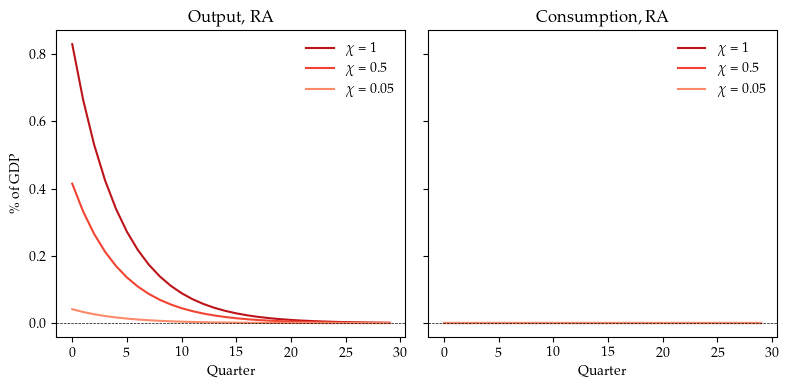

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# get three shades of red
colors_ra = plt.cm.Reds(np.linspace(0.4, 0.8, 3)[::-1])

for i, chi in enumerate([1, 0.5, 0.05]):
    # scale down eta and gamma so that (1-alpha) * eta + gamma = chi
    old_chi = ss_ra['chi']
    ss_ = ss_ra.copy()
    ss_['eta'] = ss_ra['eta'] * chi / old_chi
    ss_['gamma'] = ss_ra['gamma'] * chi / old_chi
    irfs_ra = ra.solve_impulse_linear(ss_, unknowns_td, targets_td, shock)
    
    # Plot output (Y) on the left panel
    axes[0].plot(irfs_ra['Y'][:30], label=f'$\chi$ = {chi}', color=colors_ra[i])
    
    # Plot consumption (C) on the right panel
    axes[1].plot(irfs_ra['C'][:30], label=f'$\chi$ = {chi}', color=colors_ra[i])

# Customize left panel (Output)
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_xlabel('Quarter')
axes[0].set_title('Output, RA')
axes[0].set_ylabel('\% of GDP')
axes[0].legend(frameon=False)

# Customize right panel (Consumption)
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_xlabel('Quarter')
axes[1].set_title('Consumption, RA')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('figures/lecture8_output_ra_y_and_c.pdf', bbox_inches='tight', transparent=True)

Now we compare RA output (left) with HA output (right) over the same $\chi$ sweep. With heterogeneous agents, the depreciation adds two new channels: a *real income channel* (the depreciation lowers real income, $-\alpha M\,dQ$) and a *Keynesian multiplier* ($(1-\alpha)M\,dY$). At $\chi = 1$ these two terms exactly cancel and HA coincides with RA; for low $\chi$ the real income channel dominates and depreciations become *contractionary*, which is most relevant when imports (e.g. energy, food) are hard to substitute away from.

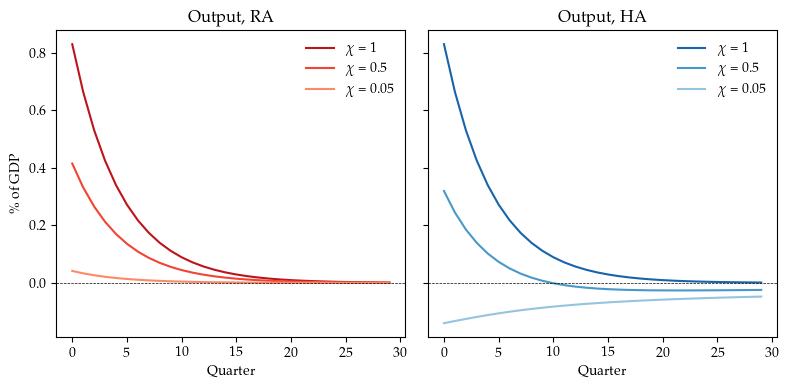

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# get three shades of red
colors_ra = plt.cm.Reds(np.linspace(0.4, 0.8, 3)[::-1])
colors_ha = plt.cm.Blues(np.linspace(0.4, 0.8, 3)[::-1])

for i, chi in enumerate([1, 0.5, 0.05]):
    # scale down eta and gamma so that (1-alpha) * eta + gamma = chi
    old_chi = ss_ra['chi']
    ss_ra_ = ss_ra.copy()
    ss_ra_['eta'] = ss_ra['eta'] * chi / old_chi
    ss_ra_['gamma'] = ss_ra['gamma'] * chi / old_chi
    irfs_ra = ra.solve_impulse_linear(ss_ra_, unknowns_td, targets_td, shock)
    
    # solve HA model with the same shock
    ss_ha_ = ss_ha.copy()
    ss_ha_['eta'] = ss_ra_['eta']
    ss_ha_['gamma'] = ss_ra_['gamma']
    irfs_ha = ha.solve_impulse_linear(ss_ha_, unknowns_td, targets_td, shock)
    
    # Plot output (Y) on the left panel
    axes[0].plot(irfs_ra['Y'][:30], label=f'$\chi$ = {chi}', color=colors_ra[i])
    
    # Plot consumption (C) on the right panel
    axes[1].plot(irfs_ha['Y'][:30], label=f'$\chi$ = {chi}', color=colors_ha[i])

# Customize left panel (Output RA)
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_xlabel('Quarter')
axes[0].set_title('Output, RA')
axes[0].set_ylabel('\% of GDP')
axes[0].legend(frameon=False)

# Customize right panel (Output HA)
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_xlabel('Quarter')
axes[1].set_title('Output, HA')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('figures/lecture8_output_ra_ha.pdf', bbox_inches='tight', transparent=True)

## Monetary policy shocks

Finally, a domestic monetary policy shock: we feed the same persistent path in as a cut to the home rate `r` rather than to `r*`. A rate cut also depreciates the currency via UIP, so the same trade-elasticity logic applies. We again sweep $\chi$ (now including a high value $2-\alpha$) and contrast RA output (left) with HA output (right).

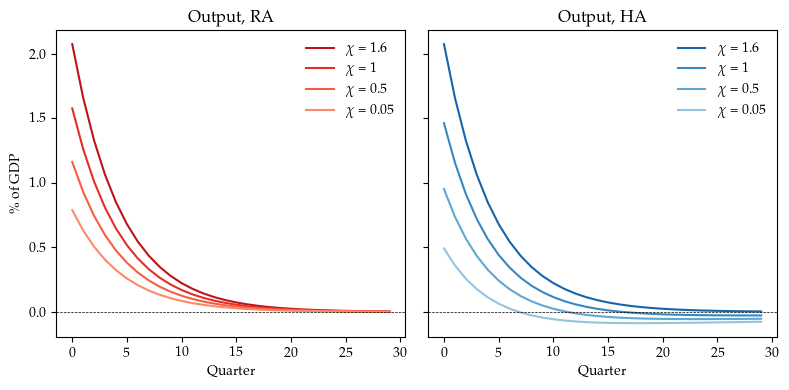

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# Define a monetary policy shock
dr = - 0.25 * 0.8 ** np.arange(T)  # transitory monetary policy shock
shock = {'r': dr}

# Get three shades of blue for HA
colors_ra = plt.cm.Reds(np.linspace(0.4, 0.8, 4)[::-1])
colors_ha = plt.cm.Blues(np.linspace(0.4, 0.8, 4)[::-1])

for i, chi in enumerate([2-ss_ha['alpha'], 1, 0.5, 0.05]):
    # Scale down eta and gamma so that (1-alpha) * eta + gamma = chi
    old_chi = ss_ra['chi']
    ss_ra_ = ss_ra.copy()
    ss_ra_['eta'] = ss_ra['eta'] * chi / old_chi
    ss_ra_['gamma'] = ss_ra['gamma'] * chi / old_chi
    irfs_ra = ra.solve_impulse_linear(ss_ra_, unknowns_td, targets_td, shock)
    
    # Solve HA model with the same shock
    ss_ha_ = ss_ha.copy()
    ss_ha_['eta'] = ss_ra_['eta']
    ss_ha_['gamma'] = ss_ra_['gamma']
    irfs_ha = ha.solve_impulse_linear(ss_ha_, unknowns_td, targets_td, shock)
    
    # Plot output (Y RA) on the left panel
    axes[0].plot(irfs_ra['Y'][:30], label=f'$\chi$ = {chi}', color=colors_ra[i])
    
    # Plot consumption (Y HA) on the right panel
    axes[1].plot(irfs_ha['Y'][:30], label=f'$\chi$ = {chi}', color=colors_ha[i])

# Customize left panel (Output RA)
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_xlabel('Quarter')
axes[0].set_title('Output, RA')
axes[0].set_ylabel('\% of GDP')
axes[0].legend(frameon=False)

# Customize right panel (Output HA)
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_xlabel('Quarter')
axes[1].set_title('Output, HA')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('figures/lecture8_monetary_shock_ra_ha.pdf', bbox_inches='tight', transparent=True)